# TP1 - UdeSA Panorámica

## Parte 1: carga, ancla y features

Este notebook integra el trabajo del grupo. La lógica reutilizable se mantiene en `panorama/` para evitar duplicación y facilitar la integración de las próximas etapas.

En esta primera sección se cargan las tres imágenes, se fija la imagen central como ancla, se convierten a escala de grises y se extraen keypoints/descriptores con SIFT.

In [1]:
from pathlib import Path
import importlib
import sys

import cv2
import matplotlib.pyplot as plt

# El notebook puede abrirse desde tp1_panoramica/ o desde la raíz del repo.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = (
    NOTEBOOK_DIR
    if (NOTEBOOK_DIR / "panorama").is_dir()
    else NOTEBOOK_DIR / "tp1_panoramica"
)
if not (PROJECT_DIR / "panorama").is_dir():
    raise FileNotFoundError(
        "No se encontró la carpeta panorama/. Abrí el notebook desde el proyecto."
    )
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

importlib.invalidate_caches()
import panorama.features as features
features = importlib.reload(features)  # Recarga cambios de features.py sin reiniciar el kernel.
adaptive_non_maximal_suppression = features.adaptive_non_maximal_suppression
extract_triplet_features = features.extract_triplet_features
load_triplet = features.load_triplet
match_triplet_to_anchor = features.match_triplet_to_anchor
matched_point_coordinates = features.matched_point_coordinates

INPUT_DIR = PROJECT_DIR / "inputs"
DATASET = "cuadro"  # Cambiar a "udesa" para correr el mismo pipeline.
ANCHOR_INDEX = 1
DETECTOR = "sift"
NFEATURES = 1500
NFEATURES_ANMS = 500
LOWE_RATIO = 0.75
MAX_MATCHES_TO_DRAW = 40
SELECTED_MATCHING_METHOD = "lowe_cross_check"
MATCHING_METHODS = {
    "lowe": "Lowe ratio",
    "cross_check": "Cross-check",
    "lowe_cross_check": "Lowe ratio + cross-check",
}

### 1. Carga de la secuencia y elección de la ancla

Usamos la imagen central (`*_1.jpg`) como ancla. Las homografías posteriores transformarán las imágenes `0` y `2` hacia este sistema de coordenadas.

In [2]:
images = load_triplet(INPUT_DIR, DATASET)
anchor_image = images[ANCHOR_INDEX]

for index, image in images.items():
    role = "ancla" if index == ANCHOR_INDEX else "lateral"
    print(f"Imagen {index} ({role}): {image.shape[1]} x {image.shape[0]} px")

Imagen 0 (lateral): 3072 x 4096 px
Imagen 1 (ancla): 3072 x 4096 px
Imagen 2 (lateral): 3072 x 4096 px


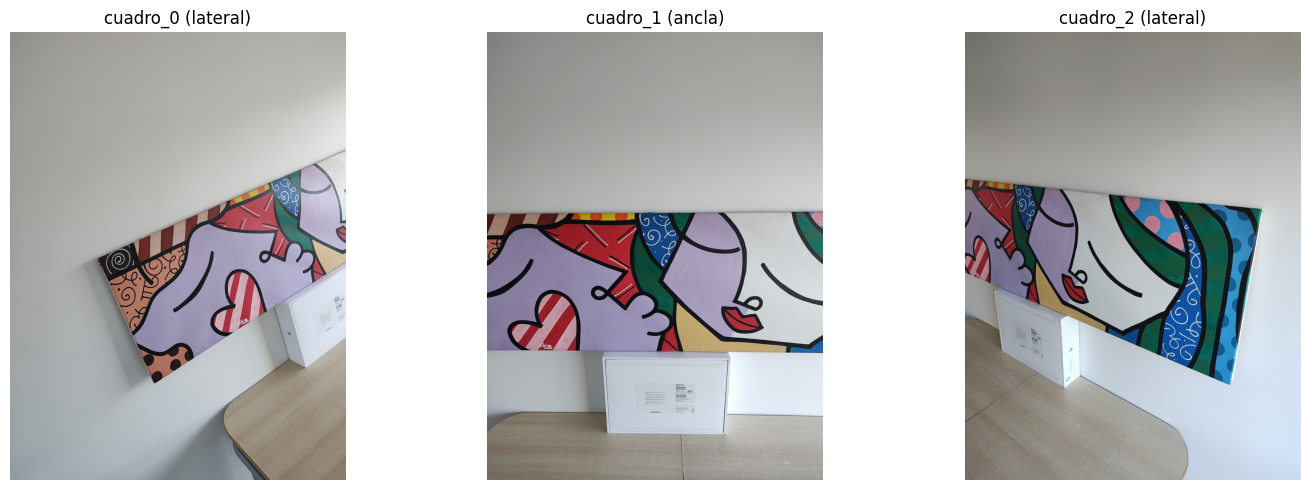

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for index, axis in enumerate(axes):
    axis.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    title = "ancla" if index == ANCHOR_INDEX else "lateral"
    axis.set_title(f"{DATASET}_{index} ({title})")
    axis.axis("off")
plt.tight_layout()

### 2 y 3. Escala de grises, keypoints y descriptores

Por ahora se extraen features iniciales. La supresión A-NMS se agregará antes del matching para distribuir mejor los puntos en toda la imagen.

#### Pipeline teorico
1. Primero detectar puntos de interes (keypoints)
    
    Objetivo: decidir si un objeto esta en una escena comparando partes reconocibles de una imagen contra otra
    
    Alta repetibilidad: encontrar el mismo punto aunque cambie el POV
    
    invarianza a iluminacion, POV, escala, rotacion

    Eficiencia computacional

    Detectores: Harris, sift, surf, shi tomasi, FAST, orb, brisk, superpoint (deep learning)

2. Keypoint vs descriptor
    Keypoint: corrdenada localmente distintiva de la img, ej esquinas, blobs, textura

    Descriptor: vector que codifica la estructura local alrededor de un keypoint. Es lo que se usa para comprar ese keypooint con otros.

3. Matching entres descriptores de dos imagenes

In [4]:
grays, keypoints, descriptors = extract_triplet_features(
    images, detector_name=DETECTOR, nfeatures=NFEATURES
)

for index in sorted(images):
    descriptor_shape = None if descriptors[index] is None else descriptors[index].shape
    print(
        f"Imagen {index}: {len(keypoints[index])} keypoints; "
        f"descriptores: {descriptor_shape}"
    )

Imagen 0: 1500 keypoints; descriptores: (1500, 128)
Imagen 1: 1500 keypoints; descriptores: (1500, 128)
Imagen 2: 1500 keypoints; descriptores: (1500, 128)


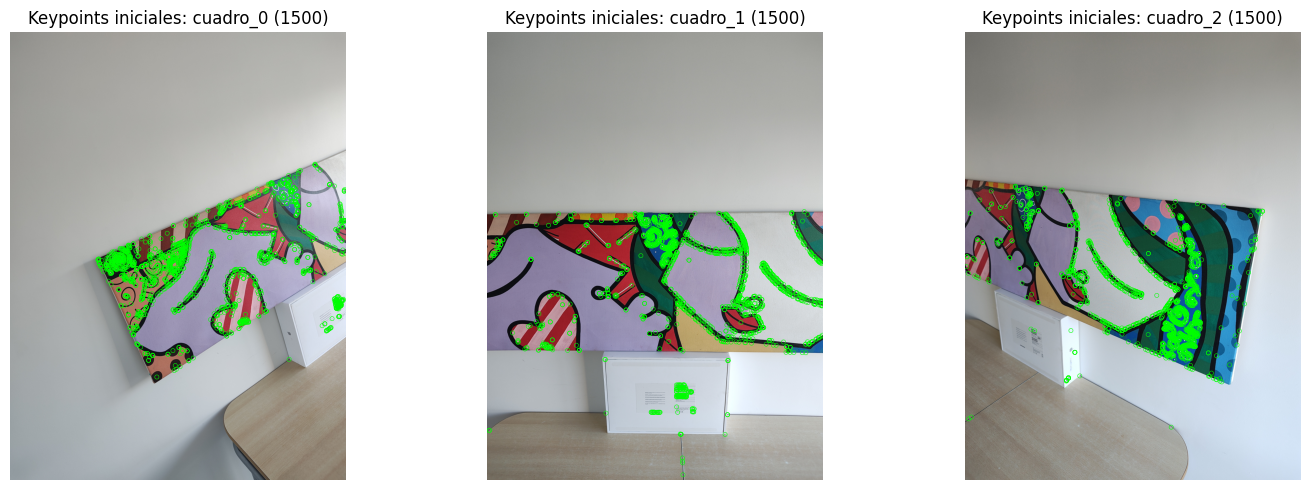

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for index, axis in enumerate(axes):
    axis.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    points = [keypoint.pt for keypoint in keypoints[index]]
    if points:
        x_coords, y_coords = zip(*points)
        # Los puntos se dibujan con tamaño fijo para que se vean al reducir fotos grandes.
        axis.scatter(
            x_coords, y_coords, s=9, facecolors="none", edgecolors="lime",
            linewidths=0.45, alpha=0.8,
        )
    axis.set_title(f"Keypoints iniciales: {DATASET}_{index} ({len(points)})")
    axis.axis("off")
plt.tight_layout()

### 4. Supresión de no máxima adaptativa (A-NMS)

A-NMS conserva puntos fuertes que están separados de otros puntos con respuesta suficiente. Así evita que los keypoints queden concentrados solamente en el sector más texturado de la imagen.

In [6]:
anms_keypoints = {}
anms_descriptors = {}

for index in sorted(images):
    anms_keypoints[index], anms_descriptors[index] = (
        adaptive_non_maximal_suppression(
            keypoints[index], descriptors[index], num_features=NFEATURES_ANMS
        )
    )
    print(
        f"Imagen {index}: {len(keypoints[index])} iniciales -> "
        f"{len(anms_keypoints[index])} luego de A-NMS"
    )

Imagen 0: 1500 iniciales -> 500 luego de A-NMS
Imagen 1: 1500 iniciales -> 500 luego de A-NMS
Imagen 2: 1500 iniciales -> 500 luego de A-NMS


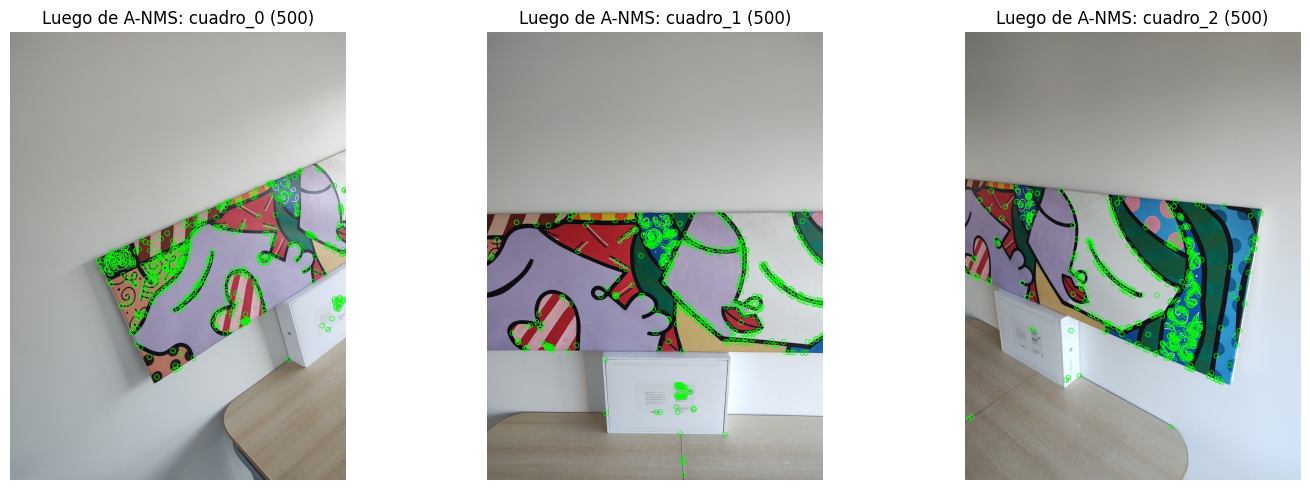

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for index, axis in enumerate(axes):
    axis.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    points = [keypoint.pt for keypoint in anms_keypoints[index]]
    if points:
        x_coords, y_coords = zip(*points)
        axis.scatter(
            x_coords, y_coords, s=12, facecolors="none", edgecolors="lime",
            linewidths=0.55, alpha=0.85,
        )
    axis.set_title(f"Luego de A-NMS: {DATASET}_{index} ({len(points)})")
    axis.axis("off")
plt.tight_layout()

### 5. Asociación de características (matching) y comparación de filtros

Se comparan tres políticas para cada imagen lateral contra la ancla: Lowe ratio, cross-check y la combinación de ambas. La combinación se usará para geometría sólo si, al inspeccionar las figuras, mantiene suficientes correspondencias correctas.

In [8]:
matching_experiments = {}

for method, method_label in MATCHING_METHODS.items():
    matching_experiments[method] = match_triplet_to_anchor(
        anms_descriptors,
        anchor_index=ANCHOR_INDEX,
        detector_name=DETECTOR,
        ratio=LOWE_RATIO,
        method=method,
    )

print(f"Comparación de métodos (Lowe ratio = {LOWE_RATIO}):")
for source_index in sorted(index for index in images if index != ANCHOR_INDEX):
    print(f"\n{DATASET}_{source_index} → {DATASET}_{ANCHOR_INDEX}")
    for method, method_label in MATCHING_METHODS.items():
        count = len(matching_experiments[method][source_index])
        print(f"  {method_label}: {count} matches")

Comparación de métodos (Lowe ratio = 0.75):

cuadro_0 → cuadro_1
  Lowe ratio: 58 matches
  Cross-check: 135 matches
  Lowe ratio + cross-check: 43 matches

cuadro_2 → cuadro_1
  Lowe ratio: 52 matches
  Cross-check: 135 matches
  Lowe ratio + cross-check: 34 matches


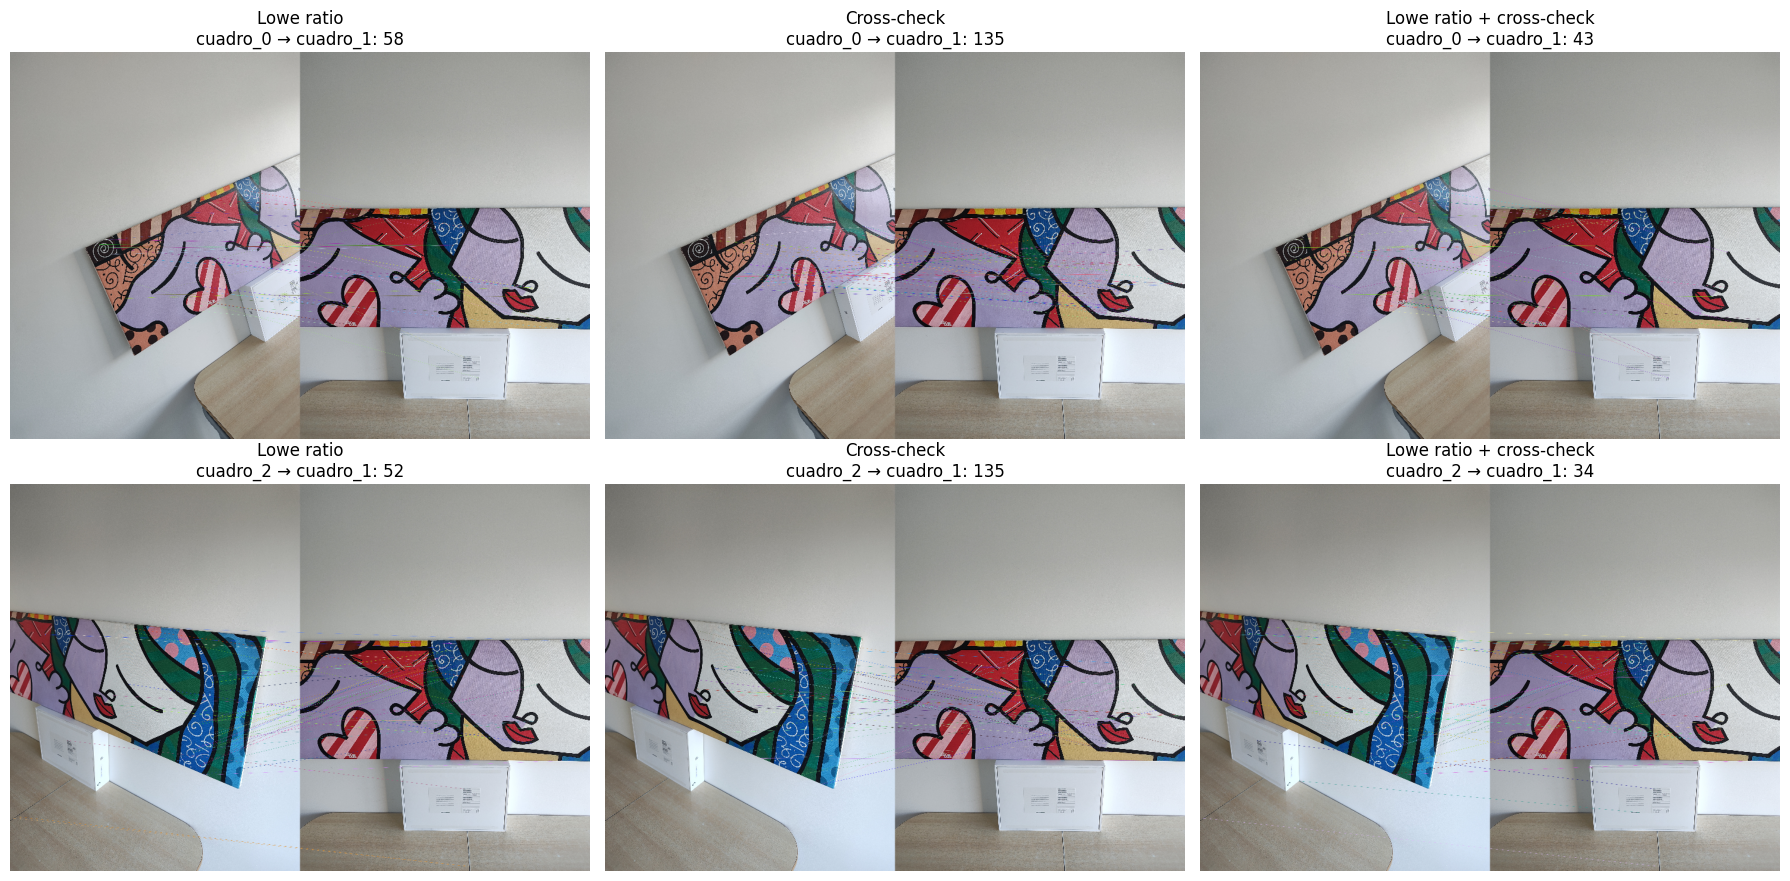

In [9]:
def make_match_preview(source_index, matches, max_matches=MAX_MATCHES_TO_DRAW):
    """Dibuja y reduce matches para que la comparación sea legible y liviana."""
    matches_to_draw = sorted(matches, key=lambda match: match.distance)[:max_matches]
    preview = cv2.drawMatches(
        images[source_index], anms_keypoints[source_index],
        images[ANCHOR_INDEX], anms_keypoints[ANCHOR_INDEX],
        matches_to_draw, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    scale = min(1500 / preview.shape[1], 650 / preview.shape[0], 1.0)
    if scale < 1.0:
        preview = cv2.resize(preview, None, fx=scale, fy=scale)
    return preview

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
source_indices = sorted(index for index in images if index != ANCHOR_INDEX)
for row, source_index in enumerate(source_indices):
    for column, (method, method_label) in enumerate(MATCHING_METHODS.items()):
        matches = matching_experiments[method][source_index]
        axes[row, column].imshow(
            cv2.cvtColor(make_match_preview(source_index, matches), cv2.COLOR_BGR2RGB)
        )
        axes[row, column].set_title(
            f"{method_label}\n{DATASET}_{source_index} → {DATASET}_{ANCHOR_INDEX}: {len(matches)}"
        )
        axes[row, column].axis("off")
plt.tight_layout()

### Selección para DLT y RANSAC

Elegimos **Lowe ratio + cross-check** como política final: Lowe ratio rechaza asociaciones ambiguas, mientras que cross-check exige consistencia mutua. Por eso suele producir menos correspondencias, pero con una proporción menor de outliers, lo cual favorece la estimación robusta de homografías. La elección se valida visualmente: las líneas deben unir detalles de la misma región de la escena y deben quedar, como mínimo, cuatro matches por cada par.

Si una pareja tuviera menos de cuatro matches o perdiera correspondencias visiblemente correctas, se puede probar `LOWE_RATIO = 0.80` o usar sólo Lowe ratio, documentando la inspección visual y el motivo del cambio.

In [10]:
matches_to_anchor = matching_experiments[SELECTED_MATCHING_METHOD]
matched_points = {}

for source_index, matches in matches_to_anchor.items():
    source_points, anchor_points = matched_point_coordinates(
        anms_keypoints[source_index], anms_keypoints[ANCHOR_INDEX], matches
    )
    matched_points[source_index] = {
        "source": source_points,
        "anchor": anchor_points,
    }
    print(
        f"Selección final - {DATASET}_{source_index} → {DATASET}_{ANCHOR_INDEX}: "
        f"{len(matches)} matches ({MATCHING_METHODS[SELECTED_MATCHING_METHOD]})"
    )

Selección final - cuadro_0 → cuadro_1: 43 matches (Lowe ratio + cross-check)
Selección final - cuadro_2 → cuadro_1: 34 matches (Lowe ratio + cross-check)


## 6. Experimento con el dataset UdeSA

Se ejecuta el mismo pipeline de features y matching sobre las imágenes provistas del edificio. Los resultados quedan guardados para comparar después con el dataset propio y para entregar las correspondencias a la etapa geométrica.

In [11]:
UDESA_DATASET = "udesa"

udesa_images = load_triplet(INPUT_DIR, UDESA_DATASET)
udesa_grays, udesa_keypoints, udesa_descriptors = extract_triplet_features(
    udesa_images, detector_name=DETECTOR, nfeatures=NFEATURES
)

udesa_anms_keypoints = {}
udesa_anms_descriptors = {}
for index in sorted(udesa_images):
    udesa_anms_keypoints[index], udesa_anms_descriptors[index] = (
        adaptive_non_maximal_suppression(
            udesa_keypoints[index],
            udesa_descriptors[index],
            num_features=NFEATURES_ANMS,
        )
    )

udesa_matching_experiments = {
    method: match_triplet_to_anchor(
        udesa_anms_descriptors,
        anchor_index=ANCHOR_INDEX,
        detector_name=DETECTOR,
        ratio=LOWE_RATIO,
        method=method,
    )
    for method in MATCHING_METHODS
}

udesa_matches_to_anchor = udesa_matching_experiments[SELECTED_MATCHING_METHOD]
udesa_matched_points = {}
for source_index, matches in udesa_matches_to_anchor.items():
    source_points, anchor_points = matched_point_coordinates(
        udesa_anms_keypoints[source_index],
        udesa_anms_keypoints[ANCHOR_INDEX],
        matches,
    )
    udesa_matched_points[source_index] = {
        "source": source_points,
        "anchor": anchor_points,
    }

try:
    results_by_dataset
except NameError:
    results_by_dataset = {}

results_by_dataset[UDESA_DATASET] = {
    "images": udesa_images,
    "keypoints": udesa_keypoints,
    "descriptors": udesa_descriptors,
    "anms_keypoints": udesa_anms_keypoints,
    "anms_descriptors": udesa_anms_descriptors,
    "matching_experiments": udesa_matching_experiments,
    "matches_to_anchor": udesa_matches_to_anchor,
    "matched_points": udesa_matched_points,
}

print(f"Dataset: {UDESA_DATASET}; ancla: {UDESA_DATASET}_{ANCHOR_INDEX}")
for index in sorted(udesa_images):
    print(
        f"Imagen {index}: {len(udesa_keypoints[index])} keypoints iniciales → "
        f"{len(udesa_anms_keypoints[index])} luego de A-NMS"
    )

for source_index in sorted(index for index in udesa_images if index != ANCHOR_INDEX):
    print(f"\n{UDESA_DATASET}_{source_index} → {UDESA_DATASET}_{ANCHOR_INDEX}")
    for method, method_label in MATCHING_METHODS.items():
        count = len(udesa_matching_experiments[method][source_index])
        print(f"  {method_label}: {count} matches")

Dataset: udesa; ancla: udesa_1
Imagen 0: 1500 keypoints iniciales → 500 luego de A-NMS
Imagen 1: 1500 keypoints iniciales → 500 luego de A-NMS
Imagen 2: 1500 keypoints iniciales → 500 luego de A-NMS

udesa_0 → udesa_1
  Lowe ratio: 84 matches
  Cross-check: 182 matches
  Lowe ratio + cross-check: 79 matches

udesa_2 → udesa_1
  Lowe ratio: 21 matches
  Cross-check: 144 matches
  Lowe ratio + cross-check: 21 matches


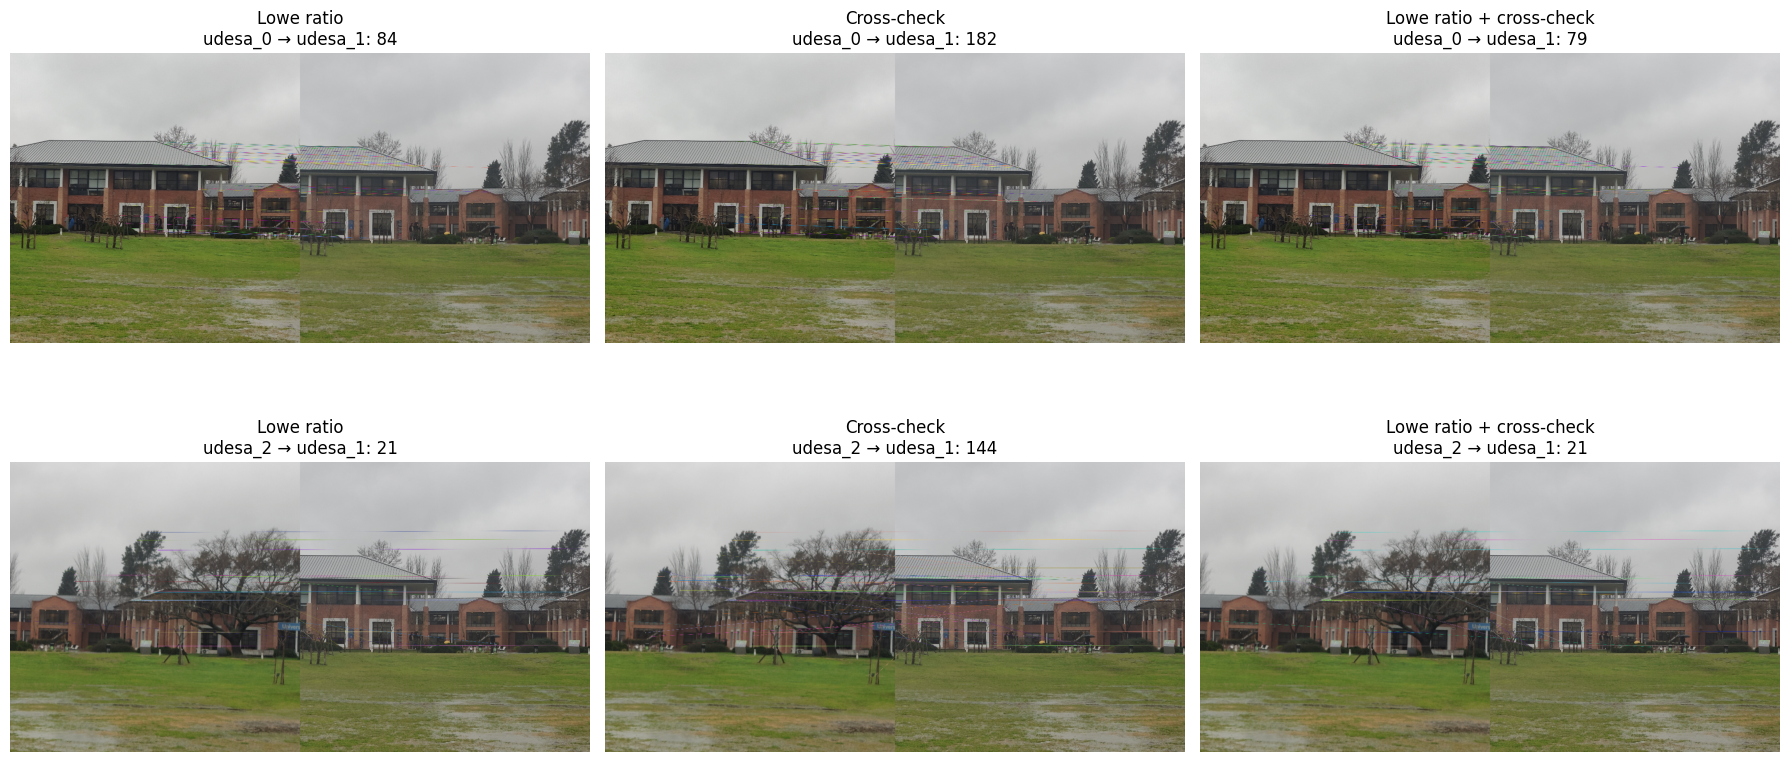

In [12]:
def make_dataset_match_preview(dataset_images, dataset_keypoints, source_index, matches):
    """Dibuja matches y reduce la imagen para mostrarla en el notebook."""
    matches_to_draw = sorted(matches, key=lambda match: match.distance)[:MAX_MATCHES_TO_DRAW]
    preview = cv2.drawMatches(
        dataset_images[source_index], dataset_keypoints[source_index],
        dataset_images[ANCHOR_INDEX], dataset_keypoints[ANCHOR_INDEX],
        matches_to_draw, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    scale = min(1500 / preview.shape[1], 650 / preview.shape[0], 1.0)
    return cv2.resize(preview, None, fx=scale, fy=scale) if scale < 1.0 else preview

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
source_indices = sorted(index for index in udesa_images if index != ANCHOR_INDEX)
for row, source_index in enumerate(source_indices):
    for column, (method, method_label) in enumerate(MATCHING_METHODS.items()):
        matches = udesa_matching_experiments[method][source_index]
        preview = make_dataset_match_preview(
            udesa_images, udesa_anms_keypoints, source_index, matches
        )
        axes[row, column].imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
        axes[row, column].set_title(
            f"{method_label}\n{UDESA_DATASET}_{source_index} → "
            f"{UDESA_DATASET}_{ANCHOR_INDEX}: {len(matches)}"
        )
        axes[row, column].axis("off")
plt.tight_layout()